[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MeteoSwiss/opendata-nwp-demos/blob/main/11_analysis_data.ipynb)
[![launch - renku](https://renkulab.io/renku-badge.svg)](https://renkulab.io/p/meteoswiss/opendata-nwp-demos/sessions/01KME52HC2FZ6ZHB30SSFG08PW/start)

# Retrieve and Visualize KENDA-CH1 Analysis Data

MeteoSwiss analysis data is produced using the [KENDA](https://www.meteoswiss.admin.ch/weather/warning-and-forecasting-systems/icon-forecasting-systems/ensemble-data-assimilation.html) (Kilometer-scale Ensemble Data Assimilation) system, which combines short-range forecasts with observations to estimate as accurately as possible the atmospheric state over Switzerland and its surroundings. This process is called data assimilation. The analysis is updated hourly and provides the initial conditions for numerical weather forecasts such as ICON-CH1-EPS and ICON-CH2-EPS.
The KENDA-CH1 analysis includes all standard parameters, which are also provided by MeteoSwiss numerical models ICON-CH1/2-EPS. 

This notebook demonstrates the full workflow for retrieving deterministic KENDA-CH1 wind gust analysis data and visualizing it. The data is provided by MeteoSwiss as part of Switzerland’s [Open Government Data (OGD) initiative](https://www.meteoswiss.admin.ch/services-and-publications/service/open-data.html).

The core functionality is provided by the [earthkit ecosystem](https://earthkit.readthedocs.io/en/latest/), developed by ECMWF to simplify loading, processing, and visualising numerical weather prediction data. The MeteoSwiss [earthkit-data-meteoswiss-opendata](https://meteoswiss.github.io/earthkit-data-meteoswiss-opendata/) configures a custom [earthkit source](https://earthkit-data.readthedocs.io/en/latest/concepts/plugins/sources_plugin.html) for accessing MeteoSwiss NWP Open Data.

---

## 🔍 **What You’ll Do in This Notebook**

 🛰️ **Retrieve**  
    Fetch deterministic KENDA-CH1 analysis data (here maximum wind gusts 10m above ground (`VMAX_10M`)) using [earthkit-data](https://earthkit-data.readthedocs.io/en/latest/) with the [earthkit-data-meteoswiss-opendata](https://meteoswiss.github.io/earthkit-data-meteoswiss-opendata/) source plugin.

 🌍 **Visualize**  
    Plot the processed data on a map using [earthkit-plots](https://earthkit-plots.readthedocs.io/en/latest/examples/guide/01-introduction.html).

---

## Retrieving Analysis Data

We distinguish between two types of analysis data: instantaneous fields at the assimilation time step and aggregated fields over the 1h short-term ICON forecasts ran between assimilation time steps. Instantaneous fields describe the atmospheric state at a specific reference time, including variables such as temperature, wind, and pressure. Those are a direct output of the analysis computed by the KENDA system. In contrast, aggregated fields represent quantities that are accumulated, averaged, minimized, or maximized over a given time period and therefore cannot be defined at a single instant. Those are not updated directly by the KENDA system and are therefore taken from the ICON forecasts ran in the assimilation cycle (so-called first guess runs). For further details, see [Numerical weather analysis KENDA-CH1](https://opendatadocs.meteoswiss.ch/e-forecast-data/e5-numerical-weather-analysis-data).

In this first part, we use [earthkit-data](https://earthkit-data.readthedocs.io/en/latest/) to load deterministic ICON-CH2-EPS precipitation forecasts from MeteoSwiss Open Data. The earthkit-data-meteoswiss-opendata plugin provides the custom earthkit source that translates the request into a query to the MeteoSwiss [STAC (SpatioTemporal Asset Catalog) API](https://data.geo.admin.ch/api/stac/static/spec/v1/api.html#tag/STAC/operation/postSearchSTAC) and resolves the matching forecast assets.

#### 📁  Browsing the STAC Catalog (Optional)

The STAC Catalog provides structured access to Switzerland’s open geospatial data.
If you'd like to explore the KENDA-CH1 analysis datasets interactively before writing code, you can browse them directly in the STAC catalog:

&nbsp;&nbsp;&nbsp;&nbsp;🔗  [Browse the KENDA-CH1 collection](https://data.geo.admin.ch/browser/#/collections/ch.meteoschweiz.ogd-analysis-kenda-ch1?.language=en)

Below is a screenshot of the KENDA-CH1 collection as seen in the STAC browser interface.


![browser-kenda.png](./images/browser-kenda.png)

⚙️ Notebook Setup

This cell installs the required dependencies when running the notebook in Google Colab or RenkuLab.

It is skipped in a local Jupyter environment, where dependencies are assumed to be installed already.

In [1]:
# 📦 Notebook setup: Colab + RenkuLab
import sys, os, pathlib

IN_COLAB = "google.colab" in sys.modules
IN_RENKU = "RENKU_BASE_URL" in os.environ or "RENKU_BASE_URL_PATH" in os.environ

if IN_COLAB:
    !git clone https://github.com/MeteoSwiss/opendata-nwp-demos.git
    %cd opendata-nwp-demos

if IN_COLAB or IN_RENKU:
    !pip install poetry && poetry config virtualenvs.in-project true && poetry install --no-ansi

    venv = pathlib.Path(".venv")
    site = venv / "lib" / f"python{sys.version_info.major}.{sys.version_info.minor}" / "site-packages"
    sys.path.insert(0, str(site))
    os.environ["ECCODES_DEFINITION_PATH"] = str((venv / "share/eccodes-cosmo-resources/definitions").resolve())

⚙️ Definition Setup

MeteoSwiss uses custom ecCodes definitions for ICON data. To correctly interpret MeteoSwiss-specific `shortName` values, you must configure the definition path by running the cell below.

In [2]:
import os
import eccodes_cosmo_resources

os.environ["ECCODES_DEFINITION_PATH"] = str(
    eccodes_cosmo_resources.get_definitions_path()
)

os.environ["ECCODES_VERSION_CHECK_OFF"] = "1"

### Creating Requests
In this part, we define which forecast data to load by specifying the model collection, variable, forecast run, and lead times. Earthkit passes these parameters to the MeteoSwiss source plugin, which builds the corresponding STAC query and retrieves the matching assets. In this example, we create a request to access maximum wind gusts 10 meter above ground (`VMAX_10M`). The request targets deterministic output at lead time +1 hour, which corresponds to the length of a first guess run in the KENDA system.

>⏰ **Analysis Availability**: Analysis data will typically be available a couple of hours after the reference time — due to the model runtime and subsequent upload time. The data remains accessible for 24 hours after upload.

In [3]:
request = {
    "collection": "ogd-analysis-kenda-ch1",
    "variable": "VMAX_10M",
    "ref_time": "latest",
    "perturbed": False,
    "lead_time": "P0DT1H"
    }

Each argument in the request serves the following purpose:

| Argument             | Description |
|----------------------|-------------|
| `collection`         | Collection to use (e.g., `ogd-analysis-kenda-ch1`). |
| `variable`           | Meteorological variable of interest (`VMAX_10M` = 10 meter maximum wind gusts). |
| `ref_time` | Initialization time of the forecast in **UTC**, provided as either:<br>- The string `"latest"` to select the newest forecast run (`ref_time`) that contains all requested lead times. All assets returned by a single request therefore share the same `ref_time`. Be cautious: separate requests (for example, for different variables) resolve `"latest"` independently and may return different `ref_time` values during data publication. <br>- [datetime.datetime](https://docs.python.org/3/library/datetime.html#datetime-objects) object (e.g.,<br> &nbsp; `datetime.datetime(2025, 5, 22, 9, 0, 0, tzinfo=datetime.timezone.utc)`) <br>- [ISO 8601](https://en.wikipedia.org/wiki/ISO_8601#Combined_date_and_time_representations) date string (e.g., `"2025-05-22T09:00:00Z"`)|
| `perturbed`          | If `True`, retrieves ensemble forecast members; if `False`, returns the deterministic forecast. |
| `lead_time`            | Forecast lead time, provided as either:<br>– [datetime.timedelta](https://docs.python.org/3/library/datetime.html#timedelta-objects) object (e.g., `datetime.timedelta(hours=1)`) <br>– [ISO 8601](https://en.wikipedia.org/wiki/ISO_8601#Durations) duration string (e.g., `"P0DT1H"`)|

### Retrieving Data
We now pass the desired request to the MeteoSwiss earthkit source. The plugin builds the STAC query, and earthkit retrieves the matching forecast data.
Each response is returned as an **[xarray.Dataset](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.html)**, which is efficient for handling multi-dimensional data.

> 💡 **Tip**: Use temporary caching with earthkit-data to skip repeated downloads — it's auto-cleaned after the session.
> *For more details, see the [earthkit-data caching docs](https://earthkit-data.readthedocs.io/en/latest/examples/cache.html)*.

> 💡 **Hint**: If you get an error message containing `HTTPError: 403 Client Error: Forbidden for url`, you may be trying to retrieve data older than 24h hours! Please adjust your requests.

In [4]:
import earthkit.data as ekd
ekd.config.set("cache-policy", "temporary")

forecast = ekd.from_source(
    "meteoswiss-opendata",
    **request,
    )

dataset = forecast.to_xarray(
    time_dims=["forecast_reference_time", "step"],
    squeeze=False
    )

print(dataset)

<xarray.Dataset> Size: 28MB
Dimensions:                  (forecast_reference_time: 1, step: 1, level: 1,
                              level_type: 1, values: 1147980)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 8B 2026...
  * step                     (step) timedelta64[ns] 8B 01:00:00
  * level                    (level) int64 8B 10
  * level_type               (level_type) <U25 100B 'height_above_ground_level'
    latitude                 (values) float64 9MB ...
    longitude                (values) float64 9MB ...
Dimensions without coordinates: values
Data variables:
    VMAX_10M                 (forecast_reference_time, step, level, level_type, values) float64 9MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF


The resulting `xarray.Dataset` has the following dimensions:

- `member` (ensemble members): 0 (for unperturbed data)
- `forecast_reference_time`: single reference time (the latest available run)
- `step`: single lead time (e.g. +1 hours)
- `level`: vertical level (e.g. 0m above ground)
- `level_type`: type of vertical level (e.g. surface)
- `values`: 1147980 spatial grid points

The spatial grid is represented by the one-dimensional `values` dimension. `latitude` and `longitude` are coordinates indexed by `values`, so each grid
point corresponds to one latitude–longitude pair. They are therefore coordinates of the data rather than separate dataset dimensions.

## 🗺️ Plot maximum wind gusts 10 meter above ground

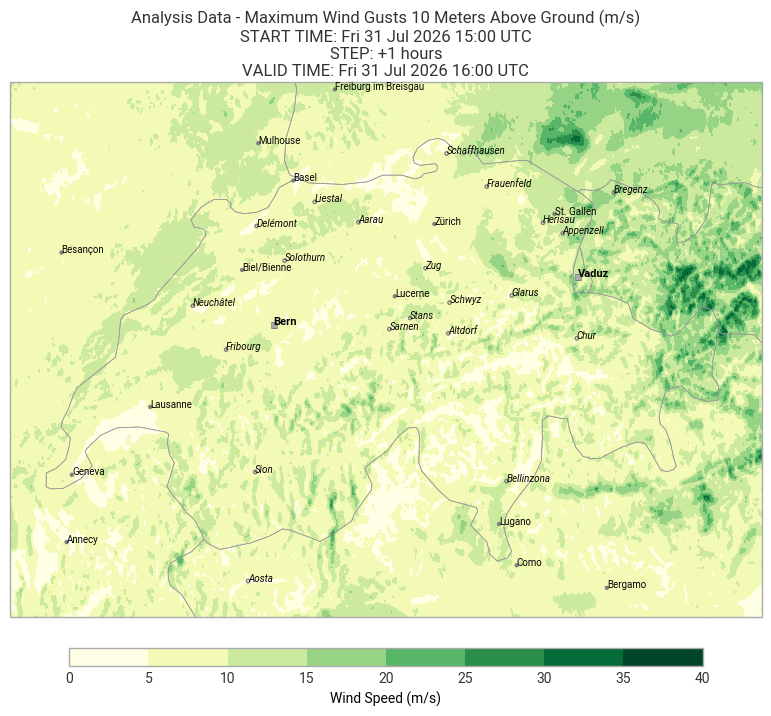

In [7]:
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
from earthkit.plots.geo import bounds, domains
from earthkit.plots.styles import Style
import earthkit


# === Setup Domain (Switzerland) ===
bbox = bounds.BoundingBox(5.7, 10.5, 45.6, 48, ccrs.Geodetic())
domain = domains.Domain.from_bbox(bbox=bbox)

# === Define Style ===
contourf_style = Style(
    colors="YlGn",
    legend_style="colorbar",
)

# === Create Map ===
chart = earthkit.plots.Map(domain="Switzerland")

# Plot filled contours and line contours
chart.contourf(dataset.VMAX_10M, x="longitude", y="latitude", style=contourf_style)

# Add map features
chart.borders()
chart.cities("high")
chart.land()
chart.legend(label="Wind Speed (m/s)")

# === Title Setup ===
# Extract reference and lead time
ref_time = pd.to_datetime(dataset.VMAX_10M.forecast_reference_time.values[0])
lead_time = dataset.VMAX_10M.step.values.astype('timedelta64[h]')
valid_time = ref_time + pd.to_timedelta(lead_time, unit="h")

# Format and apply title
title = "\n".join([
    "Analysis Data - Maximum Wind Gusts 10 Meters Above Ground (m/s)",
    f"START TIME: {ref_time.strftime('%a %d %b %Y %H:%M')} UTC",
    f"STEP: +{lead_time[0]}",
    f"VALID TIME: {valid_time[0].strftime('%a %d %b %Y %H:%M')} UTC"
])
chart.title(title)

# === Show Plot ===
chart.show()
